Assignment: End-to-End Data Preprocessing
& Feature Engineering on Google Play Store
Dataset

Dataset

Google Play Store Apps Dataset
https://www.kaggle.com/datasets/lava18/google-play-store-apps?utm_source=chatgpt.com

Problem Statement

You are working as a Data Scientist at Google Play Store Analytics Team.
The raw dataset contains missing values, inconsistent formats, outliers, categorical variables, and noisy
data. Your task is to perform complete Data Preprocessing and Feature Engineering before the dataset
can be used for Machine Learning.

In [330]:
# Learning Outcomes

# After completing this assignment, students should be able to:
# Understand dataset structure
# Handle data quality issues
# Handle missing values
# Handle duplicate records
# Handle outliers
# Perform feature transformation
# Encode categorical variables
# Scale numerical features
# Extract features from dates and text
# Create new features
# Select important features

# Prepare final dataset for Machine Learning

In [440]:
# Phase 1: Data Collection & Understanding

# Tasks

# 1. Load the dataset.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('googleplaystore.csv')



In [332]:
# 2. Display the first 10 records.
df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [333]:
# 3. Display the last 10 records.
df.tail(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10831,payermonstationnement.fr,MAPS_AND_NAVIGATION,NaN,38,9.8M,"5,000+",Free,0,Everyone,Maps & Navigation,"June 13, 2018",2.0.148.0,4.0 and up
10832,FR Tides,WEATHER,3.8,1195,582k,"100,000+",Free,0,Everyone,Weather,"February 16, 2014",6.0,2.1 and up
10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,44,619k,"1,000+",Free,0,Everyone,Books & Reference,"March 23, 2014",0.8,2.2 and up
10834,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [334]:
# 4. Check the shape of the dataset.
df.shape

(10841, 13)

In [335]:
# 5. Display all column names.
df.columns


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [336]:
# 6. Check data types of all columns.
df.dtypes



App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [337]:
# 7. Generate summary statistics.
df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [338]:
df.Installs.unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [339]:
df['Installs'] = (df['Installs'].str.replace(r'[,+]', '', regex=True))
# df['Installs'] = df['Installs'].fillna('0')
df['Installs'] = df['Installs'].replace('Free','0').astype(int)


In [340]:
df['Size'] = df['Size'].str.replace('M','',regex=False)
df['Size'] = pd.to_numeric(df['Size'],errors='coerce')


In [341]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [342]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Reviews'] = df['Reviews'].astype('Int64')

In [343]:
# df['Reviews'] = df['Reviews'].fillna('0')


In [344]:
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [345]:
df['Price'] = df['Price'].str.lstrip('$')


In [346]:

df['Price'] = pd.to_numeric(df['Price'],errors='coerce')

In [347]:
# df['Price'] = df['Price'].fillna('0')

In [348]:
df['Price'] = df['Price'].astype(float)

In [349]:
df.loc[df['Reviews'].isna(), 'Reviews']

10472    <NA>
Name: Reviews, dtype: Int64

In [350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10840 non-null  Int64  
 4   Size            8829 non-null   float64
 5   Installs        10841 non-null  int32  
 6   Type            10840 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: Int64(1), float64(3), int32(1), object(8)
memory usage: 1.0+ MB


In [351]:
# 8. Identify:
# Numerical Features
nums_col = df.select_dtypes(include=['int32','float64']).columns
print(nums_col)
# Categorical Features
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)


Index(['Rating', 'Size', 'Installs', 'Price'], dtype='object')
Index(['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')


In [352]:
#  2. Which feature has the highest number of unique values?
df.nunique().sort_values(ascending=False)
df.nunique().idxmax()

'App'

In [353]:
# Questions

# 1. How many rows and columns are present?
# There are 13 coloumns and 10841 rows are present
## 3. Which column may act as an identifier?
# App coloumn must be identifier it has most no. of unique values.
# 4. Which columns appear to need cleaning?
# Rating', 'Reviews', 'Size', 'Installs', 'Price' almost all numentical coloumns and other caltegorical coloumns which having nul values Current Ver', 'Android Ver'.

Phase 2: Data Quality Assessment

In [354]:
# Tasks

# 1. Check for duplicate records.

df[df.duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,NaN,5000000,Free,0.0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,NaN,10000000,Free,0.0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,NaN,5000000,Free,0.0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37.0,10000000,Free,0.0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,NaN,1000000,Free,0.0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,Wunderlist: To-Do List & Tasks,PRODUCTIVITY,4.6,404610,NaN,10000000,Free,0.0,Everyone,Productivity,"April 6, 2018",Varies with device,Varies with device
8654,"TickTick: To Do List with Reminder, Day Planner",PRODUCTIVITY,4.6,25370,NaN,1000000,Free,0.0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
8658,ColorNote Notepad Notes,PRODUCTIVITY,4.6,2401017,NaN,100000000,Free,0.0,Everyone,Productivity,"June 27, 2018",Varies with device,Varies with device
10049,Airway Ex - Intubate. Anesthetize. Train.,MEDICAL,4.3,123,86.0,10000,Free,0.0,Everyone,Medical,"June 1, 2018",0.6.88,5.0 and up


In [355]:

# 2. Count duplicate rows.

df.duplicated().sum()

483

In [356]:

# 3. Remove duplicate rows.
df.drop_duplicates(inplace=True)



In [357]:
# 4. Verify the dataset shape after removing duplicates.
df.shape
# after

(10358, 13)

In [358]:
df.shape 
# before

(10358, 13)

In [359]:
# # Questions
# 1. How many duplicate records were found?
# there where 483 duplicate records were found
# 2. Why should duplicate records be removed before model building?

# Duplicate records can bias the model because the same data is repeated multiple times.
# This makes the model learn certain patterns more than it should, leading to inaccurate results.

# 3. What problems can duplicate data create?

# Duplicate data can:

# Reduce data quality 
# Bias the model 
# Produce inaccurate predictions 
# Distort statistics (mean, count, distribution) 
# Increase training time 

In [360]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Phase 3: Data Type Correction

In [361]:


# The following columns are stored as text:

# Installs
# Price
# Size
# Reviews

# Tasks

# Convert values such as:

# 1,000+
# 10,000+
# 1M
# 20M
# Varies with device
# $4.99

# into meaningful numerical values.
# Questions

# 1. Why are these columns unsuitable for Machine Learning in their current form?

# They are stored as text (object datatype) and contain symbols, units,
# and non-numeric values, while Machine Learning models require numerical data.

# 2. What preprocessing steps were required to convert them?

# Removed special characters (+, ,, $, M), handled values 
# like "Varies with device", converted columns to numeric datatype, 
# and treated invalid values as missing (NaN).

# 3. Which column was the most challenging to clean and why?

# Size was the most challenging because 
# it contained mixed formats such as M, k, 
# and "Varies with device", requiring multiple cleaning steps before conversion.

Phase 4: Missing Value Treatment

In [362]:


# Tasks

# 1. Identify missing values.
df.isna().sum()


App                  0
Category             0
Rating            1465
Reviews              1
Size              1842
Installs             0
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [363]:
# 2. Calculate the percentage of missing values in each column. 
missing_values = ( df.isna().sum() / len(df) ) * 100 
print(missing_values)

App                0.000000
Category           0.000000
Rating            14.143657
Reviews            0.009654
Size              17.783356
Installs           0.000000
Type               0.009654
Price              0.009654
Content Rating     0.009654
Genres             0.000000
Last Updated       0.000000
Current Ver        0.077235
Android Ver        0.028963
dtype: float64


In [364]:
# 3. Categorize columns based on missing value percentage.
low_persentage_values = missing_values[missing_values<5]
mid_pv = missing_values[(missing_values>=5) & (missing_values<15)]
high_pv = missing_values[missing_values>=15] 
print(low_persentage_values)
print('------------------')
print(mid_pv)
print('------------------')
print(high_pv) 

App               0.000000
Category          0.000000
Reviews           0.009654
Installs          0.000000
Type              0.009654
Price             0.009654
Content Rating    0.009654
Genres            0.000000
Last Updated      0.000000
Current Ver       0.077235
Android Ver       0.028963
dtype: float64
------------------
Rating    14.143657
dtype: float64
------------------
Size    17.783356
dtype: float64


In [365]:
# Numerical Columns

# Apply:
# Mean Imputation
df[nums_col] = df[nums_col].fillna(df[nums_col].mean())

# Median Imputation
df[nums_col] = df[nums_col].fillna(df[nums_col].median())

# Compare the results.
# Categorical Columns
# Apply:
# Mode Imputation
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode())
# Constant Value Imputation
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [366]:
df['Rating']

0        4.100000
1        3.900000
2        4.700000
3        4.500000
4        4.300000
           ...   
10836    4.500000
10837    5.000000
10838    4.189542
10839    4.500000
10840    4.500000
Name: Rating, Length: 10358, dtype: float64

In [367]:
# Questions

# 1. Which columns contain the highest number of missing values?
# Size    17.783356 
# 2. Which imputation method is most suitable for the Rating column?
# Its a numarical coloumn so mean or median will be best.
# 3. Why is handling missing data important?

# Handling missing data is important because missing values can lead to inaccurate analysis, biased results,
# and errors during model training. It improves data quality and model performance.



Phase 5: Handling Inconsistent Data

Tasks

Identify and clean:
Currency symbols
Commas

Plus signs
Text values inside numerical columns
Invalid entries
Special characters
Examples:

1,000+
$4.99
19M
Varies with device 



In [368]:
# Questions

# 1. Why is data consistency important?
# It ensures accurate analysis, reliable results, and better model performance.

# 2. What issues arise when numerical columns contain text values?
# Calculations, statistical analysis, and machine learning models cannot work properly on text values.

# 3. How did you handle inconsistent records?
# Cleaned the data by removing symbols/text, converting columns to the correct datatype, 
# and handling missing or invalid values.


 Phase 6: Outlier Detection & Treatment


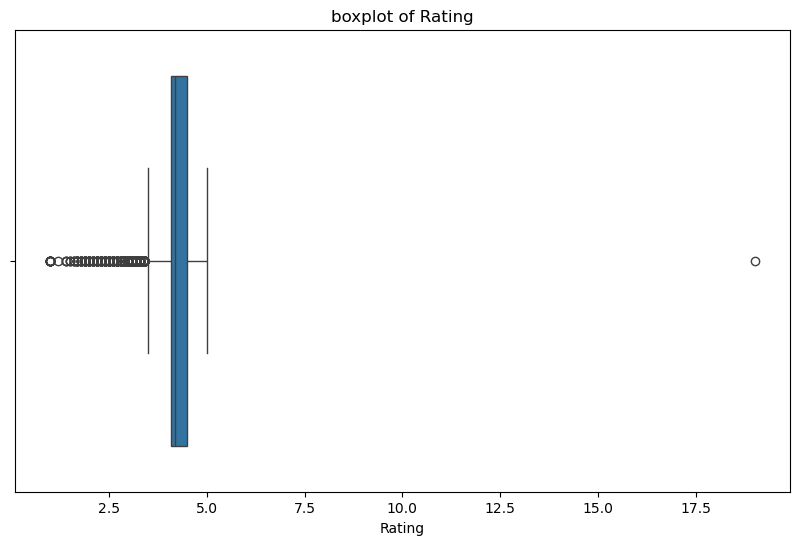

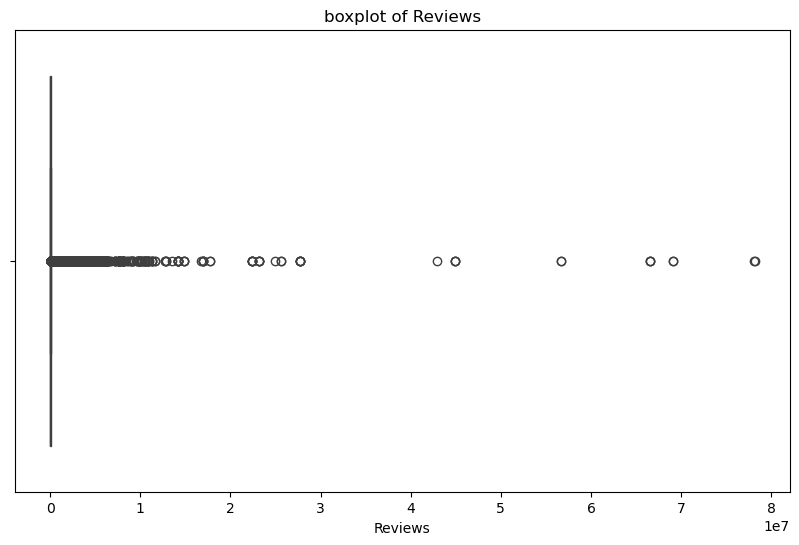

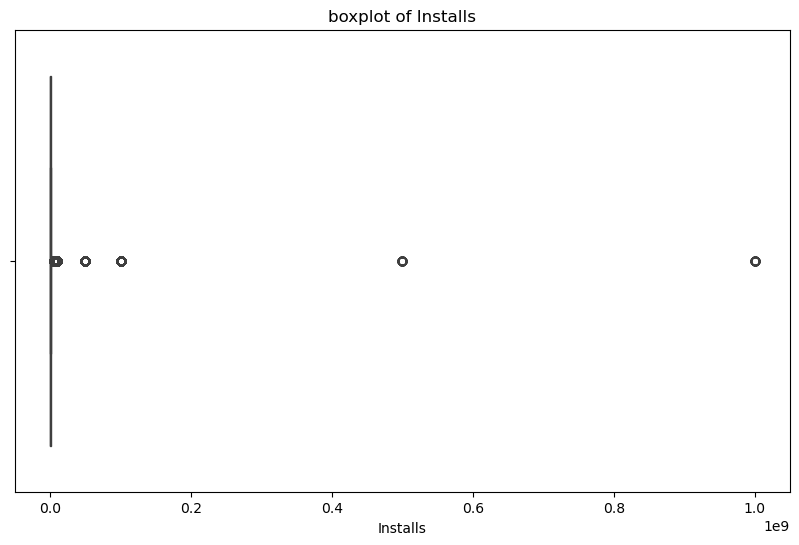

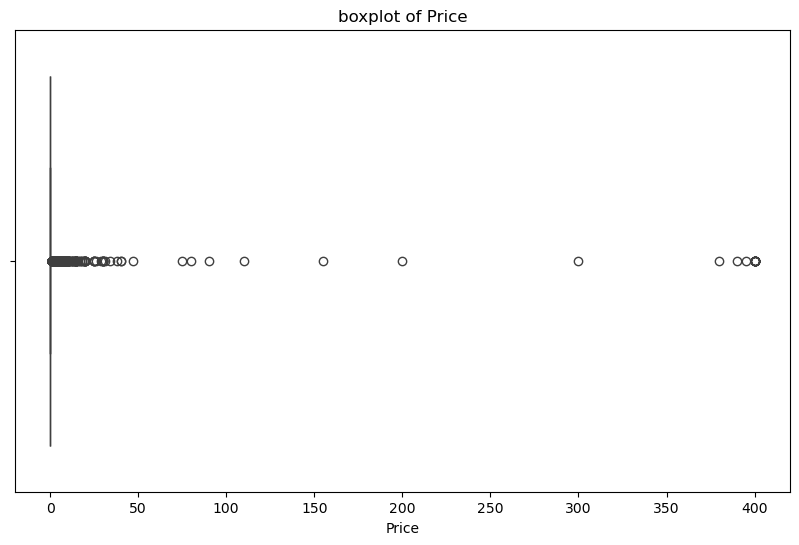

In [369]:

# Features

# Analyze:

# Rating
# Reviews
# Installs
# Price

# Tasks

# 1. Visualize outliers using boxplots.
c = ['Rating','Reviews', 'Installs', 'Price']
for i in c:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[i])
    plt.title(f'boxplot of {i}')
    plt.show()






In [370]:
# 2. Detect outliers using the IQR method.

c = ['Rating','Reviews', 'Installs', 'Price']

for i in c:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    iqr = q3-q1

    low_b = q1 - 1.5*iqr
    upper_b = q3 + 1.5*iqr

    outliers = df[( df[i]<low_b ) | ( df[i]>upper_b ) ]

    print(f'{i}: {len(outliers)} outliers')

Rating: 724 outliers
Reviews: 1870 outliers
Installs: 2566 outliers
Price: 766 outliers


In [371]:
# 3. Detect outliers using Z-score.

from scipy.stats import zscore

c = ['Rating', 'Reviews', 'Installs', 'Price']

for i in c:

    z_scores = zscore(df[i])

    outliers = df[abs(z_scores) > 3]

    print(f'{i}: {len(outliers)} outliers')

Rating: 173 outliers
Reviews: 0 outliers
Installs: 110 outliers
Price: 23 outliers


In [372]:
# 4. Remove outliers.
col = ['Rating', 'Price']
for i in col:

    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df = df[
        (df[i] >= lower) &
        (df[i] <= upper)
    ]

In [373]:
# # 5. Apply outlier capping.

# cols = ['Rating', 'Reviews', 'Installs', 'Price']

# for i in cols:

#     q1 = df[i].quantile(0.25)
#     q3 = df[i].quantile(0.75)

#     iqr = q3 - q1

#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     df[i] = df[i].clip(lower=lower, upper=upper)

# # 6. Compare both approaches.

# # Outlier Removal deletes records containing extreme values, 
# # while Outlier Capping limits extreme values within a range without removing records.
# # Capping is often preferred because it preserves the dataset size.


In [374]:
# Questions

# 1. Which feature contains the most outliers?
# Installs
# 2. Which outlier treatment method performed better?

# Outlier Capping performed better because it reduces the impact 
# of extreme values while preserving all records. 

# 3. Why can outliers negatively affect model performance?

# Outliers can distort statistical measures, bias model training, 
# reduce accuracy, and lead to poor predictions.



Phase 7: Feature Transformation


In [375]:
# Tasks

# Check skewness of:

# Reviews
# Installs
# Price

c = ['Reviews','Installs','Price']
for i in c:
    print(i,':',df[i].skew() )




Reviews : 16.23419579408655
Installs : 9.390254604609554
Price : 0.0


In [376]:
# Apply:
# Log Transformation

c = ['Reviews','Installs','Price']
for i in c:
    df[i] = np.log(df[i])

c:\Users\GULAB\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)
c:\Users\GULAB\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [377]:

c = ['Reviews','Installs','Price']
for i in c:
    print(i,':',df[i].skew() )

Reviews : <NA>
Installs : nan
Price : nan


c:\Users\GULAB\anaconda3\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


In [378]:
# np.log1p()


c = ['Reviews','Installs','Price']
for i in c:
    df[i] = np.log1p(df[i])

c:\Users\GULAB\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:672: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs2, **kwargs)
c:\Users\GULAB\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [379]:
# Square Root Transformation

c = ['Reviews','Installs','Price']
for i in c:
    df[i] = np.sqrt(df[i])

In [380]:
c = ['Reviews','Installs','Price']
for i in c:
    print(i,':',df[i].skew() )

Reviews : <NA>
Installs : -3.431687268635596
Price : nan


In [381]:
# Questions

# 1. Which features were highly skewed?
# Reviews is highly skewed
# 2. Which transformation reduced skewness most effectively?

# Log Transformation usually reduces skewness most effectively for highly right-skewed data.

# 3. Why is skewness a problem for some machine learning models?

# Skewness can distort data distribution, affect model assumptions, 
# and reduce the performance of algorithms that work best with normally distributed data.

Phase 8: Feature Encoding


In [382]:

# Tasks

# Apply Label Encoding on:

# Type

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Type'] = le.fit_transform(df['Type'])





In [383]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Free': 0, 'Unknown': 1}


In [384]:
# Apply One-Hot Encoding on:
# Category
# Content Rating
# Genres

df = pd.get_dummies(
    df,
    columns=['Category', 'Content Rating', 'Genres'],
    dtype=int
)

In [385]:
df.shape

(8920, 164)

In [386]:
# Questions

# 1. Why is One-Hot Encoding preferred for Category and Genres?

# Because Category and Genres are nominal (unordered) features. 
# One-Hot Encoding avoids creating a false order between categories.

# 2. When should Label Encoding be used?

# Label Encoding should be used for ordinal (ordered) categorical features 
# where the categories have a meaningful order (e.g., Low, Medium, High).

# 3. What are the disadvantages of One-Hot Encoding?

# It increases the number of columns,
# consumes more memory, and can make the dataset sparse when there are many unique categories.

Phase 9: Feature Scaling


In [387]:

# Tasks

# Apply:
# StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['Rating', 'Reviews', 'Installs', 'Price']
df[cols] = scaler.fit_transform(df[cols])


c:\Users\GULAB\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\GULAB\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\GULAB\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [388]:
print(df[cols].head())

     Rating   Reviews  Installs  Price
0 -0.586643 -0.157315 -0.126137    NaN
1 -1.237387  0.139139  0.409801    NaN
2  1.365588  0.612738  0.648123    NaN
3  0.714845  0.682389  0.849957    NaN
4  0.064101  0.139139  0.213936    NaN


In [389]:
# MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ['Rating', 'Reviews', 'Installs', 'Price']

df[cols] = scaler.fit_transform(df[cols])



c:\Users\GULAB\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:701: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\GULAB\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:718: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [390]:
df[cols].head()

,Rating,Reviews,Installs,Price
0,0.400000,0.781350,0.868762,NaN
1,0.266667,0.835869,0.927423,NaN
2,0.800000,0.922966,0.953509,NaN
3,0.666667,0.935775,0.975601,NaN
4,0.533333,0.835869,0.905985,NaN


In [391]:


# Questions

# 1. Compare the outputs of both scalers.

# StandardScaler: Data has mean = 0 and standard deviation = 1; values can be negative or positive.
# MinMaxScaler: Data is scaled to a fixed range, usually 0 to 1.

# 2. Which algorithms benefit from scaling?

# Linear Regression, Logistic Regression, KNN, SVM, K-Means, PCA, and Neural Networks.

# 3. Which scaler would you choose for this dataset and why?

# StandardScaler, because the numerical features (Reviews, Installs, Price) have a wide range of values.
# StandardScaler standardizes the data and is commonly preferred 
# for models like Linear Regression and Logistic Regression.


Phase 10: Feature Extraction

In [392]:
# A. Date Feature Extraction

# Column:

# Last Updated

# Convert it into datetime format and extract:
# Year
# Month
# Day
# Quarter
# Day Name 

In [393]:
df['Last Updated']

0         January 7, 2018
1        January 15, 2018
2          August 1, 2018
3            June 8, 2018
4           June 20, 2018
               ...       
10836       July 25, 2017
10837        July 6, 2018
10838    January 20, 2017
10839    January 19, 2015
10840       July 25, 2018
Name: Last Updated, Length: 8920, dtype: object

In [394]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [395]:
df['Year'] = df['Last Updated'].dt.year

In [396]:
df['Month'] = df['Last Updated'].dt.month

In [397]:
df['Day'] = df['Last Updated'].dt.day

In [398]:
df['Quater'] = df['Last Updated'].dt.quarter

In [399]:
df['datename'] = df['Last Updated'].dt.day_name()

In [400]:
df['datename']

0           Sunday
1           Monday
2        Wednesday
3           Friday
4        Wednesday
           ...    
10836      Tuesday
10837       Friday
10838       Friday
10839       Monday
10840    Wednesday
Name: datename, Length: 8920, dtype: object

In [401]:
df.columns

Index(['App', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Last Updated', 'Current Ver', 'Android Ver',
       ...
       'Genres_Video Players & Editors',
       'Genres_Video Players & Editors;Creativity',
       'Genres_Video Players & Editors;Music & Video', 'Genres_Weather',
       'Genres_Word', 'Year', 'Month', 'Day', 'Quater', 'datename'],
      dtype='object', length=169)

In [402]:
df['Year'].value_counts().sort_values(ascending=False)

Year
2018    6244
2017    1487
2016     615
2015     346
2014     129
2013      71
2012      17
2011      10
2010       1
Name: count, dtype: int64

In [403]:
df['month name'] = df['Last Updated'].dt.month_name()

In [404]:
df['month name'].value_counts().idxmax()

'July'

In [405]:
# Questions

# 1. Which year contains the highest number of app updates?
# 2018    6244
# 2. Which month contains the highest number of updates?
# 7 , July

 B. Android Version Extraction

In [406]:
df.columns

Index(['App', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Last Updated', 'Current Ver', 'Android Ver',
       ...
       'Genres_Video Players & Editors;Creativity',
       'Genres_Video Players & Editors;Music & Video', 'Genres_Weather',
       'Genres_Word', 'Year', 'Month', 'Day', 'Quater', 'datename',
       'month name'],
      dtype='object', length=170)

In [407]:
df['Android Ver'].unique()

array(['4.0.3 and up', '4.2 and up', '4.4 and up', '2.3 and up',
       '3.0 and up', '4.1 and up', '4.0 and up', '2.3.3 and up',
       'Varies with device', '2.2 and up', '5.0 and up', '6.0 and up',
       '1.6 and up', '1.5 and up', '2.1 and up', '7.0 and up',
       '5.1 and up', '4.3 and up', '4.0.3 - 7.1.1', '2.0 and up',
       '3.2 and up', '4.4W and up', '7.1 and up', '7.0 - 7.1.1',
       '8.0 and up', '5.0 - 8.0', '3.1 and up', '2.0.1 and up',
       '4.1 - 7.1.1', 'Unknown', '5.0 - 6.0', '1.0 and up', '2.2 - 7.1.1',
       '5.0 - 7.1.1'], dtype=object)

In [408]:


# Extract the minimum Android version from values such as:

# 4.1 and up
# 5.0 and up
# 6.0 and up

# Create:



df['Minimum_Android_Version'] = df['Android Ver'].str.split(' ').str[0]

df['Minimum_Android_Version'] = df['Minimum_Android_Version'].replace(['Varies','Unknown'],np.nan) 

df['Minimum_Android_Version'] = df['Minimum_Android_Version'].str.replace('W', '')

In [409]:
df['Minimum_Android_Version'] = pd.to_numeric(df['Minimum_Android_Version'],errors='coerce')

In [410]:
df['Minimum_Android_Version'].value_counts().sort_values(ascending=False)

Minimum_Android_Version
4.1    2137
4.0    1145
4.4     781
2.3     531
5.0     471
4.2     342
3.0     186
4.3     185
2.2     162
2.1      98
1.6      73
6.0      44
7.0      26
2.0      26
3.2      24
5.1      19
1.5      12
3.1       8
8.0       4
7.1       3
1.0       2
Name: count, dtype: int64

In [411]:

# Questions

# 1. Which Android version appears most frequently?
# 4.1      2137
# 2. Why might this feature be useful?
# The Minimum_Android_Version feature helps analyze app compatibility with Android devices 
# and can improve machine learning models by providing useful information about the minimum OS requirement.

 Phase 11: Feature Creation


In [412]:
# Phase 11: Feature Creation

# Create the following features.

# Feature 1

# Reviews_Per_Install

# Formula:

# Reviews / Installs


df['Reviews_Per_Install'] = df['Reviews']/df['Installs']

In [413]:
# Feature 2

# Paid_App_Flag

# Paid = 1
# Free = 0


df['Paid_App_Flag'] = df['Type'].apply(lambda x: 1 if x == 'Paid' else 0)

In [414]:
df['Paid_App_Flag'].value_counts()

Paid_App_Flag
0    8920
Name: count, dtype: int64

In [415]:
df['Type'].unique()

array([0, 1])

In [416]:
# Feature 3

# App_Age

# Formula:

# Current Year - Update Year 

Current_Year = 2026

df['App_Age'] = Current_Year - df['Year']

In [417]:
df['App_Age']

0         8
1         8
2         8
3         8
4         8
         ..
10836     9
10837     8
10838     9
10839    11
10840     8
Name: App_Age, Length: 8920, dtype: int32

In [418]:
# Feature 4

# Popularity_Score

# Formula:

# Rating * Reviews

df['Popularity_Score'] = df['Rating']*df['Reviews']

In [419]:
df['Popularity_Score']

0        0.312540
1        0.222898
2        0.738372
3        0.623850
4        0.445797
           ...   
10836    0.480480
10837    0.542652
10838    0.230296
10839    0.512692
10840    0.629273
Name: Popularity_Score, Length: 8920, dtype: float64

In [420]:
# Feature 5

# Revenue_Potential

# Formula:

# Price * Installs

df['Revenue_Potential'] = df['Price']*df['Installs']

In [421]:
df['Revenue_Potential']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
10836   NaN
10837   NaN
10838   NaN
10839   NaN
10840   NaN
Name: Revenue_Potential, Length: 8920, dtype: float64

In [ ]:

# Feature 6

# Category_Average_Rating

# Calculate the average rating for each category and assign it to every app.

# df['Category_Average_Rating'] = df.groupby('Category')['Rating'].transform('mean')

In [424]:
# df.groupby('Category')['Category_Average_Rating'].first().idxmax()

In [425]:
# Questions

# 1. Which category has the highest average rating? 'HEALTH_AND_FITNESS'
# 2. Which category has the highest revenue potential?
# 3. Are paid apps more popular than free apps?
# 4. Which newly created feature seems most useful? Paid_App_Flag

 Phase 12: Feature Selection


In [426]:
df.columns

Index(['App', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Last Updated', 'Current Ver', 'Android Ver',
       ...
       'Day', 'Quater', 'datename', 'month name', 'Minimum_Android_Version',
       'Reviews_Per_Install', 'Paid_App_Flag', 'App_Age', 'Popularity_Score',
       'Revenue_Potential'],
      dtype='object', length=176)

In [427]:

# Assume:

# Rating

# is the target variable.
# Tasks

# 1. Perform Correlation Analysis.

cols = [
    'Rating',
    'Reviews',
    'Installs',
    'Price'
]

df[cols]



,Rating,Reviews,Installs,Price
0,0.400000,0.781350,0.868762,NaN
1,0.266667,0.835869,0.927423,NaN
2,0.800000,0.922966,0.953509,NaN
3,0.666667,0.935775,0.975601,NaN
4,0.533333,0.835869,0.905985,NaN
...,...,...,...,...
10836,0.666667,0.720720,0.855517,NaN
10837,1.000000,0.542652,0.748287,NaN
10838,0.459695,0.500976,0.819592,NaN
10839,0.666667,0.769038,0.819592,NaN


In [428]:
correlation = df[cols].corr()

print(correlation)

            Rating   Reviews  Installs  Price
Rating    1.000000 -0.011249 -0.005746    NaN
Reviews  -0.011249  1.000000  0.857621    NaN
Installs -0.005746  0.857621  1.000000    NaN
Price          NaN       NaN       NaN    NaN


In [429]:
print(correlation['Rating'])

Rating      1.000000
Reviews    -0.011249
Installs   -0.005746
Price            NaN
Name: Rating, dtype: float64


In [430]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# sns.heatmap(correlation, annot=True, cmap='coolwarm')
# plt.show()

In [431]:
# 2. Identify highly correlated features.
# correlation['Rating'].sort_values(ascending=False)

In [433]:
# 3. Apply SelectKBest.
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop('Rating', axis=1)
X = X.select_dtypes(include='number')   # Keep only numerical columns

y = df['Rating']

selector = SelectKBest(score_func=f_regression, k=3)

X_new = selector.fit_transform(X, y)

print(X.columns[selector.get_support()])

ValueError: Input X contains NaN.
SelectKBest does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:

# 4. Apply Random Forest Feature Importance.
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = df.drop('Rating', axis=1)
X = X.select_dtypes(include='number')

y = df['Rating']

model = RandomForestRegressor(random_state=42)

model.fit(X, y)

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)


    Feature  Importance
0   Reviews    0.528216
1      Size    0.360271
2  Installs    0.111513
3     Price    0.000000


In [ ]:
# 5. Compare results from all methods.
# Correlation Analysis measures the linear relationship between each feature and the target.
# SelectKBest selects the top features using a statistical test (f_regression).
# Random Forest Feature Importance ranks features based on how much they contribute to the model's predictions.

In [ ]:
# Questions

# 1. Which features have the strongest relationship with Rating? Reviews    0.528216


# 2. Which features can be removed?


# 3. Why is feature selection important? 
# Feature selection removes irrelevant features, reduces overfitting, 
# improves model performance, and decreases training time.

 Phase 13: Train-Test Split

In [438]:
# Tasks

# 1. Separate features (X) and target variable (y).
# 2. Use:

# Rating

# as the target.




from sklearn.model_selection import train_test_split
X = df.drop('Rating', axis=1)

X = X.select_dtypes(include='number')   

y = df['Rating']


# 3. Perform an 80:20 Train-Test Split.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 4. Display the shapes of:
# X_train
# X_test
# y_train
# y_test

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (8672, 0)
X_test : (2169, 0)
y_train: (8672,)
y_test : (2169,)


In [ ]:
# Questions

# 1. Why do we split data before training? 
# We split the data to train the model on one set and evaluate 
# its performance on unseen data, helping us measure how well it generalizes.


# 2. What problems occur if we train and test on the same dataset? 
# The model may overfit, giving unrealistically high accuracy 
# because it has already seen the test data. It won't accurately reflect performance on new, unseen data.

Phase 14: Build a Preprocessing Pipeline


In [441]:
# Using:

# ColumnTransformer
# Pipeline

# Create an automated preprocessing pipeline that performs:
# Missing Value Handling
# Encoding
# Scaling
# in a single workflow.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_cols = X.select_dtypes(include='number').columns

cat_cols = X.select_dtypes(include='object').columns


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


X_processed = preprocessor.fit_transform(X)

In [ ]:
# Questions

# 1. What are the advantages of using a Pipeline?

# Cleaner code
# Less manual work
# Prevents forgetting preprocessing steps
# Easy to reuse on new data
# Helps avoid data leakage by applying the same transformations consistently

# # 2. How does a Pipeline help prevent data leakage? 

# A Pipeline ensures that preprocessing steps such as imputation, scaling, 
# and encoding are learned only from the training data (fit).
#  The same learned transformations are then applied to the test
#  data (transform) without using any information from the test set. 
# This prevents data leakage and gives a more reliable evaluation of the model.

# In simple wording
# A Pipeline first learns how to clean and prepare only the training data. 
# Then, it applies the same steps to the test data without learning anything from it. 
# This keeps the test data completely separate,
# prevents data leakage, and gives a fair evaluation of the model.

 Final Deliverables

In [ ]:
# Submit:

# 1. google_playstore_cleaned.csv
# 2. google_playstore_feature_engineered.csv
# 3. Jupyter Notebook ( .ipynb )
# 4. A report containing:
# Challenges faced during preprocessing
# Important features discovered
# Key business insights

# Final conclusions



In [ ]:
# Reflection Questions

# 1. Which preprocessing step had the greatest impact on the dataset?

# Data cleaning and converting text columns (Installs, Price, Size, Reviews) 
# into numerical values had the greatest impact because it made the data suitable for analysis and machine learning.


# 2. Which feature engineering technique was most useful?

# Creating the Reviews_Per_Install feature was the 
# most useful because it measures user engagement by relating reviews to installs.


# 3. Which newly created feature would you use in a machine learning model and why?

# I would use Category_Average_Rating because 
# it captures the average performance of each app category and can improve rating prediction.


# 4. What challenges did you face while working with real-world data?

# The main challenges were handling missing values, inconsistent formats 
# (such as "Varies with device" and "4.4W"), text stored as numbers, duplicate records, and outliers.


# 5. If you were building an App Rating Prediction System, which features would you select and why?

# I would select features such as Reviews, Installs, Price, Category_Average_Rating, Reviews_Per_Install, 
# Paid_App_Flag, and App_Age because they provide useful information about 
# app popularity, user engagement, pricing, category performance, and app maintenance, all of which can influence app ratings.

